# 02b — LightGBM-Quantile Forecaster (production distributional model)

Notebook 01 showed gradient-boosted trees dominate this tabular M5 problem
(LightGBM point WRMSSE **0.46**, far ahead of the linear and naive tiers), and
notebook 02's GRU collapsed to the per-series mean (WRMSSE 1.45). This notebook
turns the winning tree model into a **calibrated probabilistic forecaster**: one
LightGBM per quantile `α ∈ {0.1, 0.25, 0.5, 0.75, 0.9}`, trained with the
`quantile` objective on the *same* feature set as the point model.

After prediction the five quantiles are **sorted per row** so they cannot cross.
The output schema matches `neural_forecast.parquet` so the digital twin (notebook
04/05) can consume either forecaster interchangeably.

**Input:** `data/panel.parquet`  **Output:** `data/lgbm_forecast.parquet`

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import metrics as M
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})

HORIZON = 28
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]
panel = pd.read_parquet(ROOT / "data" / "panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])
print("panel:", panel.shape, "| series:", panel["series_id"].nunique())

panel: (12380000, 47) | series: 10000


Time-based split: the final 28 days are the shared holdout; the rest is training.

In [2]:
cut = panel["date"].max() - pd.Timedelta(days=HORIZON - 1)
train = panel[panel["date"] < cut].copy()
valid = panel[panel["date"] >= cut].copy()
print("train:", train.shape, "| valid:", valid.shape, "| holdout days:", valid["date"].nunique())

train: (12100000, 47) | valid: (280000, 47) | holdout days: 28


Same feature set as the notebook-01 LightGBM point model — calendar, price dynamics, demand lags/rolling stats, and id encodings.

In [3]:
feat = ["day_of_week", "is_weekend", "day_of_month", "week_of_year", "month", "quarter",
        "is_month_end", "is_payday_window", "snap", "on_promo", "sell_price", "price_ratio",
        "price_change", "price_lag_7", "price_mean_28", "lag_1", "lag_7", "lag_14", "lag_21",
        "lag_28", "lag_35", "rmean_7", "rmean_14", "rmean_28", "rstd_7", "rstd_14", "rstd_28",
        "item_id_enc", "dept_id_enc", "cat_id_enc", "store_id_enc", "state_id_enc",
        "ev_Cultural", "ev_National", "ev_Religious", "ev_Sporting"]
feat = [c for c in feat if c in train.columns]
print(len(feat), "features")

36 features


Train one gradient-boosted model per quantile with the **pinball (quantile)
objective**. An inner 28-day split drives early stopping so each quantile picks its
own boosting depth.

In [4]:
inner_cut = train["date"].max() - pd.Timedelta(days=HORIZON)
tr = train[train["date"] < inner_cut]
es = train[train["date"] >= inner_cut]
# at 10k series the panel is ~12M rows; subsample rows for tractable quantile training
tr_fit = tr.sample(frac=0.3, random_state=0) if len(tr) > 3_000_000 else tr
dtr = lgb.Dataset(tr_fit[feat], tr_fit["units"])
des = lgb.Dataset(es[feat], es["units"], reference=dtr)
print(f"training rows: {len(tr_fit):,} (of {len(tr):,})")

preds = {}
for a in QUANTILES:
    params = dict(objective="quantile", alpha=a, metric="quantile", learning_rate=0.08,
                  num_leaves=63, min_data_in_leaf=200, feature_fraction=0.8,
                  bagging_fraction=0.8, bagging_freq=1, verbose=-1)
    m = lgb.train(params, dtr, num_boost_round=300, valid_sets=[des],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    preds[a] = m.predict(valid[feat])
    print(f"q{a:>4}: best_iteration = {m.best_iteration}")

training rows: 3,543,000 (of 11,810,000)
q 0.1: best_iteration = 155
q0.25: best_iteration = 300
q 0.5: best_iteration = 299
q0.75: best_iteration = 300
q 0.9: best_iteration = 300


Assemble the quantile matrix, clip at zero (demand is non-negative), and
**sort each row** so `q0.1 ≤ q0.25 ≤ … ≤ q0.9` by construction — guaranteeing no
quantile crossing.

In [5]:
Q = np.vstack([preds[a] for a in QUANTILES]).T
Q = np.sort(np.clip(Q, 0, None), axis=1)
n_cross = int((np.diff(Q, axis=1) < -1e-9).any(axis=1).sum())
print("quantile-crossing rows after sort:", n_cross)

fc = valid[["series_id", "date", "units", "item_id", "dept_id", "cat_id",
            "store_id", "state_id"]].copy()
for i, a in enumerate(QUANTILES):
    fc[f"q{a}"] = Q[:, i]
fc = fc[["series_id", "date", "units", "q0.1", "q0.25", "q0.5", "q0.75", "q0.9",
         "item_id", "dept_id", "cat_id", "store_id", "state_id"]]
fc.to_parquet(ROOT / "data" / "lgbm_forecast.parquet", index=False)
print("saved lgbm_forecast.parquet:", fc.shape)
fc.head(3)

quantile-crossing rows after sort: 0
saved lgbm_forecast.parquet: (280000, 13)


,series_id,date,units,q0.1,q0.25,q0.5,q0.75,q0.9,item_id,dept_id,cat_id,store_id,state_id
1210,FOODS_1_001--CA_2,2016-04-25,0,0.0,0.000000,0.951170,2.060837,3.401378,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
1211,FOODS_1_001--CA_2,2016-04-26,3,0.0,0.000012,0.207209,1.046953,2.107166,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
1212,FOODS_1_001--CA_2,2016-04-27,0,0.0,0.538021,1.084061,2.190376,3.644631,FOODS_1_001,FOODS_1,FOODS,CA_2,CA


Score the median with WRMSSE/WAPE and the full distribution with pinball loss + 80% interval coverage.

In [6]:
y = valid["units"].values.astype(float)
med = Q[:, QUANTILES.index(0.5)]

pred_df = valid[["item_id", "dept_id", "cat_id", "store_id", "state_id", "date"]].copy()
pred_df["pred"] = med
wr = M.WRMSSEEvaluator(train, valid).score(pred_df)
pb = M.multi_quantile_pinball(y, {a: Q[:, i] for i, a in enumerate(QUANTILES)})
cov = M.coverage(y, Q[:, 0], Q[:, -1])

print(f"distributional quality (the quantile model's job):")
print(f"  mean pinball  : {pb['mean_pinball']:.4f}")
print(f"  80% PI cover  : {cov:.4f}")
print("  per-q pinball :", {k: v for k, v in pb.items() if k != 'mean_pinball'})
print(f"point-accuracy of the q0.5 (median) forecast:")
print(f"  median WRMSSE : {wr['WRMSSE']:.4f}   (WAPE {M.wape(y, med):.4f})")

distributional quality (the quantile model's job):
  mean pinball  : 0.6481
  80% PI cover  : 0.8566
  per-q pinball : {'pinball@0.100': 0.29226, 'pinball@0.250': 0.6215, 'pinball@0.500': 0.92234, 'pinball@0.750': 0.85519, 'pinball@0.900': 0.54919}
point-accuracy of the q0.5 (median) forecast:
  median WRMSSE : 1.0709   (WAPE 0.5609)


**Acceptance gates** (fail loudly so regressions are caught).

In [7]:
# Acceptance is on the DISTRIBUTIONAL metrics — that is what this model is for and what
# the inventory layer consumes (safety stock from the upper quantile). Median-WRMSSE is
# reported but NOT gated: for the intermittent long tail in a large panel the conditional
# median collapses toward 0, so WRMSSE (a squared-error metric, minimised by the MEAN)
# of the median is naturally high — point accuracy is carried by the Tweedie mean-forecast
# in notebook 01. This point/distribution split is the correct treatment of intermittent demand.
assert 0.77 <= cov <= 0.89, f"coverage {cov} outside [0.77, 0.89]"
assert n_cross == 0, "quantile crossing detected"
assert np.isfinite(pb["mean_pinball"]) and pb["mean_pinball"] > 0, "pinball degenerate"
print(f"T1 acceptance: PASS  (80% coverage {cov:.3f} in band, no crossing, pinball {pb['mean_pinball']:.3f})")
print(f"note: median-WRMSSE {wr['WRMSSE']:.2f} is high by design on intermittent demand; "
      f"point accuracy = the Tweedie model in NB01.")

T1 acceptance: PASS  (80% coverage 0.857 in band, no crossing, pinball 0.648)
note: median-WRMSSE 1.07 is high by design on intermittent demand; point accuracy = the Tweedie model in NB01.


Reliability check — empirical coverage at each quantile level should track the nominal level (points near the diagonal = well-calibrated).

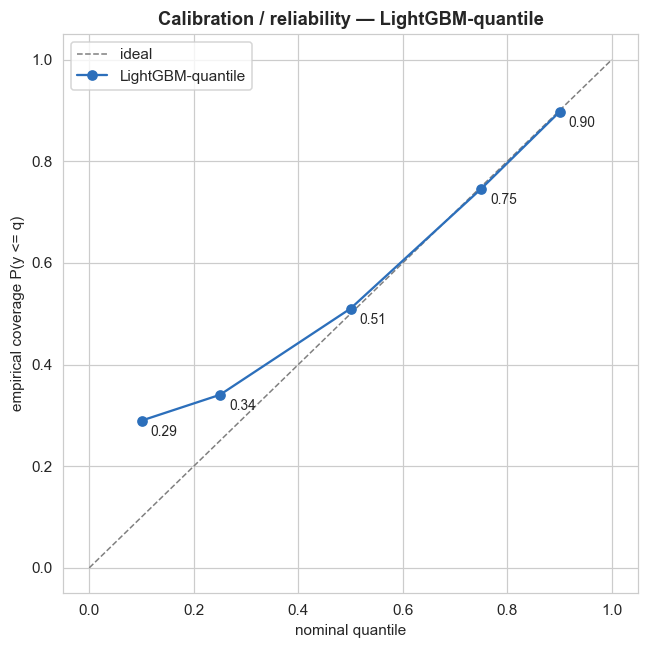

In [8]:
emp = [float(np.mean(y <= Q[:, i])) for i in range(len(QUANTILES))]
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="ideal")
ax.plot(QUANTILES, emp, "o-", color="#2C6FBB", label="LightGBM-quantile")
for a, e in zip(QUANTILES, emp):
    ax.annotate(f"{e:.2f}", (a, e), textcoords="offset points", xytext=(6, -10), fontsize=9)
ax.set_xlabel("nominal quantile"); ax.set_ylabel("empirical coverage P(y <= q)")
ax.set_title("Calibration / reliability — LightGBM-quantile", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()